# Transformations Module Walkthrough

This notebook demonstrates the core capabilities of `pysatl_core.transformations`:

1. Affine transformations (`aX + b`).
2. Binary transformations (`X + Y`, `X - Y`, `X * Y`, `X / Y`).
3. Finite weighted mixtures.
4. Characteristic materialization via approximation methods.

All examples use NumPy-array semantics for characteristic evaluation.

## Setup

In [1]:
from __future__ import annotations

from typing import Any

import matplotlib.pyplot as plt
import numpy as np

from pysatl_core import (
    BinaryOperationName,
    CharacteristicName,
    FamilyName,
    ParametricFamilyRegister,
    configure_families_register,
)
from pysatl_core.transformations.approximations import (
    CDFMonotoneSplineApproximation,
    PDFLinearInterpolationApproximation,
    PPFMonotoneSplineApproximation,
)
from pysatl_core.transformations.operations import affine, binary, finite_mixture

In [2]:
# Register built-in families in the global registry.
configure_families_register()

normal_family = ParametricFamilyRegister.get(FamilyName.NORMAL)
uniform_family = ParametricFamilyRegister.get(FamilyName.CONTINUOUS_UNIFORM)
exp_family = ParametricFamilyRegister.get(FamilyName.EXPONENTIAL)

# Base distributions used below.
normal_left = normal_family.distribution(parametrization_name="meanStd", mu=-0.5, sigma=0.8)
normal_right = normal_family.distribution(parametrization_name="meanStd", mu=1.0, sigma=0.6)

uniform_a = uniform_family.distribution(
    parametrization_name="standard", lower_bound=0.0, upper_bound=1.0
)
uniform_b = uniform_family.distribution(
    parametrization_name="standard", lower_bound=1.0, upper_bound=2.0
)
uniform_den = uniform_family.distribution(
    parametrization_name="standard", lower_bound=1.5, upper_bound=2.5
)

exp_base = exp_family.distribution(parametrization_name="rate", lambda_=1.25)

## Plotting Helpers

All helper utilities are grouped here to keep example cells focused on transformations.

In [3]:
def _method_values(distribution: Any, characteristic: str, grid: np.ndarray) -> np.ndarray:
    """Evaluate a characteristic on a grid and cast to float array."""
    method = distribution.query_method(characteristic)
    return np.asarray(method(grid), dtype=float)


def plot_curve(
    ax: plt.Axes,
    x: np.ndarray,
    y: np.ndarray,
    *,
    label: str,
    title: str,
    xlabel: str = "x",
    ylabel: str = "value",
) -> None:
    """Draw a single curve on an axis."""
    ax.plot(x, y, label=label)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25)
    ax.legend()


def plot_hist_with_optional_pdf(
    ax: plt.Axes,
    samples: np.ndarray,
    *,
    label: str,
    pdf_distribution: Any | None = None,
    x_grid: np.ndarray | None = None,
    bins: int = 80,
) -> None:
    """Draw a normalized histogram and optionally overlay PDF."""
    ax.hist(samples, bins=bins, density=True, alpha=0.45, label=label)
    if pdf_distribution is not None and x_grid is not None:
        pdf_values = _method_values(pdf_distribution, CharacteristicName.PDF, x_grid)
        ax.plot(x_grid, pdf_values, color="black", linewidth=1.8, label="PDF")
    ax.grid(alpha=0.25)
    ax.legend()


def show_moments(label: str, distribution: Any) -> None:
    """Print mean and variance if available."""
    mean = distribution.query_method(CharacteristicName.MEAN)
    var = distribution.query_method(CharacteristicName.VAR)
    print(f"{label:<28} mean={mean(): .6f} var={var(): .6f}")

## 1) Affine Transformation

The `affine(...)` operation builds a `DerivedDistribution` with transformed characteristics and support.

In [4]:
affine_pos = affine(normal_left, scale=1.8, shift=0.4)
affine_neg = affine(uniform_a, scale=-2.0, shift=1.0)

print("Transformation name:", affine_pos.transformation_name)
print("Base roles:", tuple(affine_pos.bases.keys()))
print("Positive-scale support:", affine_pos.support)
print("Negative-scale support:", affine_neg.support)

Transformation name: affine
Base roles: ('base',)
Positive-scale support: ContinuousSupport(left=-inf, right=inf, left_closed=False, right_closed=False)
Negative-scale support: ContinuousSupport(left=-1.0, right=1.0, left_closed=True, right_closed=True)


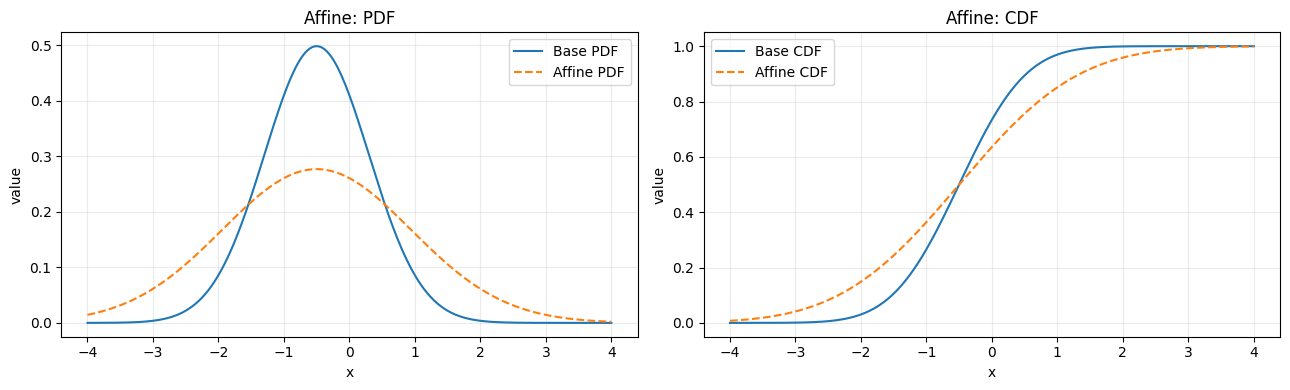

In [5]:
x_aff = np.linspace(-4.0, 4.0, 500)

base_pdf = _method_values(normal_left, CharacteristicName.PDF, x_aff)
aff_pdf = _method_values(affine_pos, CharacteristicName.PDF, x_aff)
base_cdf = _method_values(normal_left, CharacteristicName.CDF, x_aff)
aff_cdf = _method_values(affine_pos, CharacteristicName.CDF, x_aff)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_curve(axes[0], x_aff, base_pdf, label="Base PDF", title="Affine: PDF")
axes[0].plot(x_aff, aff_pdf, linestyle="--", label="Affine PDF")
axes[0].legend()

plot_curve(axes[1], x_aff, base_cdf, label="Base CDF", title="Affine: CDF")
axes[1].plot(x_aff, aff_cdf, linestyle="--", label="Affine CDF")
axes[1].legend()

plt.tight_layout()
plt.show()

## 2) Binary Transformations and Operator Sugar

Operator overloads (`+`, `-`, `*`, `/`) are thin wrappers around transformation primitives.
The explicit `binary(...)` API gives the same result with direct operation selection.

In [6]:
sum_d = normal_left + normal_right
sub_d = normal_left - normal_right
mul_d = uniform_a * uniform_b
div_d = binary(uniform_b, uniform_den, operation=BinaryOperationName.DIV)

show_moments("normal_left + normal_right", sum_d)
show_moments("normal_left - normal_right", sub_d)
show_moments("uniform_a * uniform_b", mul_d)
show_moments("uniform_b / uniform_den", div_d)

normal_left + normal_right   mean= 0.500000 var= 1.000000
normal_left - normal_right   mean=-1.500000 var= 1.000000
uniform_a * uniform_b        mean= 0.750000 var= 0.215278
uniform_b / uniform_den      mean= 0.766238 var= 0.035101


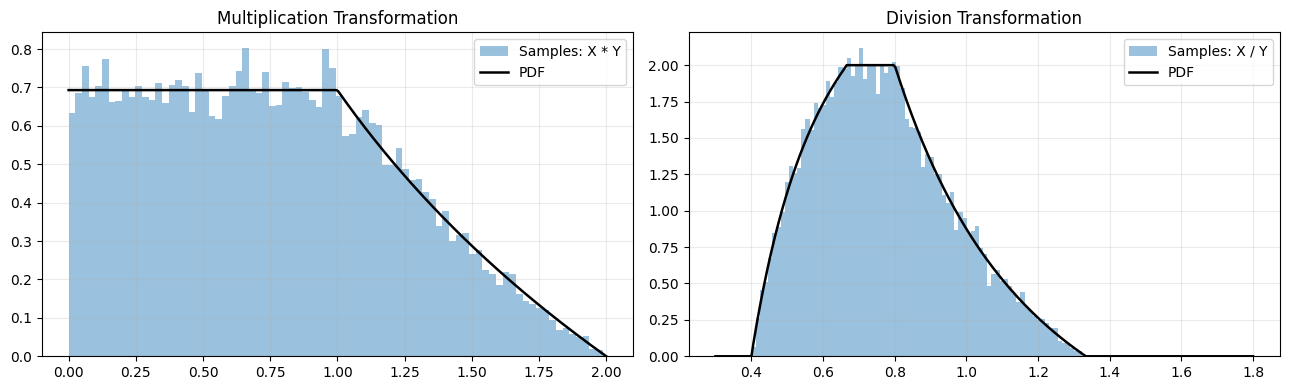

In [7]:
rng_size = 20_000
x_mul = np.linspace(0.0, 2.0, 300)
x_div = np.linspace(0.3, 1.8, 300)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_hist_with_optional_pdf(
    axes[0],
    mul_d.sample(rng_size),
    label="Samples: X * Y",
    pdf_distribution=mul_d,
    x_grid=x_mul,
)
axes[0].set_title("Multiplication Transformation")

plot_hist_with_optional_pdf(
    axes[1],
    div_d.sample(rng_size),
    label="Samples: X / Y",
    pdf_distribution=div_d,
    x_grid=x_div,
)
axes[1].set_title("Division Transformation")

plt.tight_layout()
plt.show()

## 3) Finite Mixture

A finite mixture combines multiple component distributions with validated non-negative weights that sum to one.

In [8]:
mixture_d = finite_mixture(
    [
        (0.35, normal_left),
        (0.50, normal_right),
        (0.15, exp_base),
    ]
)

print("Mixture transformation name:", mixture_d.transformation_name)
print("Mixture support:", mixture_d.support)
print("Mixture components:", len(mixture_d.components))
print("Mixture weights:", mixture_d.weights)

show_moments("finite mixture", mixture_d)

Mixture transformation name: finite_mixture
Mixture support: ContinuousSupport(left=-inf, right=inf, left_closed=False, right_closed=False)
Mixture components: 3
Mixture weights: [0.35 0.5  0.15]
finite mixture               mean= 0.445000 var= 0.985475


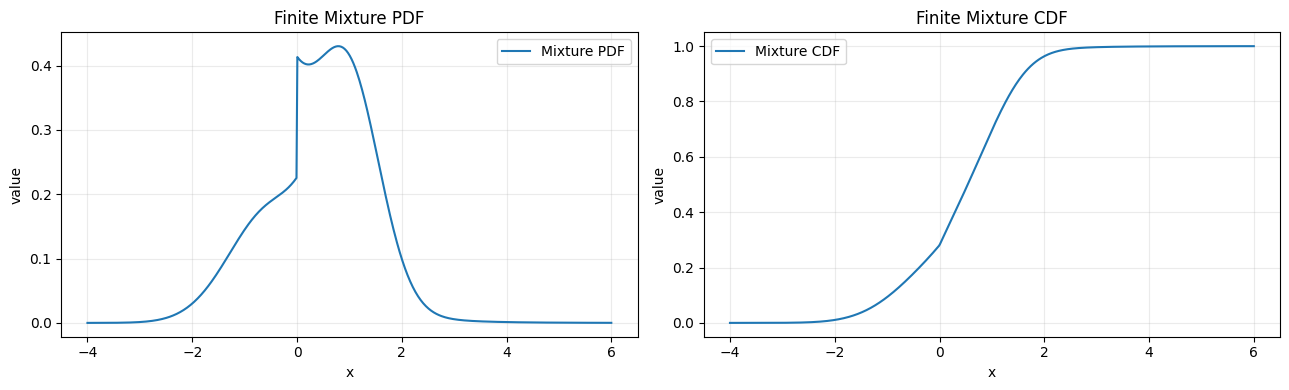

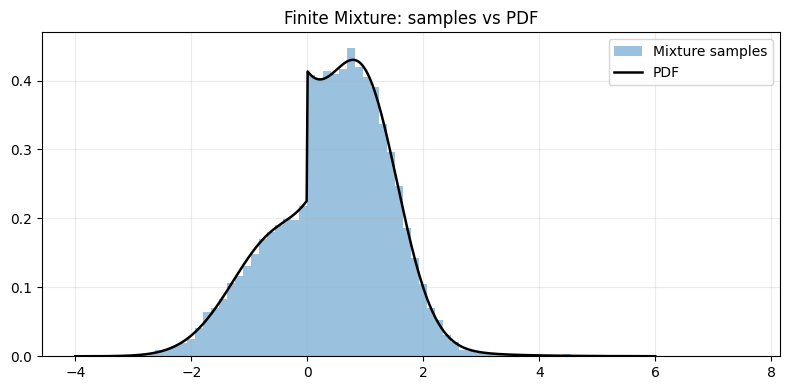

In [9]:
x_mix = np.linspace(-4.0, 6.0, 600)
mix_pdf = _method_values(mixture_d, CharacteristicName.PDF, x_mix)
mix_cdf = _method_values(mixture_d, CharacteristicName.CDF, x_mix)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_curve(axes[0], x_mix, mix_pdf, label="Mixture PDF", title="Finite Mixture PDF")
plot_curve(axes[1], x_mix, mix_cdf, label="Mixture CDF", title="Finite Mixture CDF")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
plot_hist_with_optional_pdf(
    ax,
    mixture_d.sample(30_000),
    label="Mixture samples",
    pdf_distribution=mixture_d,
    x_grid=x_mix,
)
ax.set_title("Finite Mixture: samples vs PDF")
plt.tight_layout()
plt.show()

## 4) Approximation of Transformed Characteristics

`DerivedDistribution.approximate(...)` materializes selected characteristics with interpolation/spline methods.
The resulting distribution keeps transformation metadata and exposes approximated methods.

In [10]:
approximated_affine = affine_pos.approximate(
    methods={
        CharacteristicName.PDF: PDFLinearInterpolationApproximation(
            n_grid=513,
            lower_limit=-4.0,
            upper_limit=4.0,
        ),
        CharacteristicName.CDF: CDFMonotoneSplineApproximation(
            n_grid=513,
            lower_limit_prob=1e-6,
            upper_limit_prob=1e-6,
        ),
        CharacteristicName.PPF: PPFMonotoneSplineApproximation(
            n_grid=513,
            lower_limit=0.0,
            upper_limit=1.0,
        ),
    }
)

print("Approximated transformation name:", approximated_affine.transformation_name)
print(
    "Loop analytical flag (PDF):",
    approximated_affine.loop_is_analytical(
        CharacteristicName.PDF,
        "PySATL_default_analytical_computation",
    ),
)

Approximated transformation name: approximation
Loop analytical flag (PDF): False


Max |PDF error|: 4.07083947989717e-06
Max |CDF error|: 6.537550822915961e-08
Max |PPF error|: inf


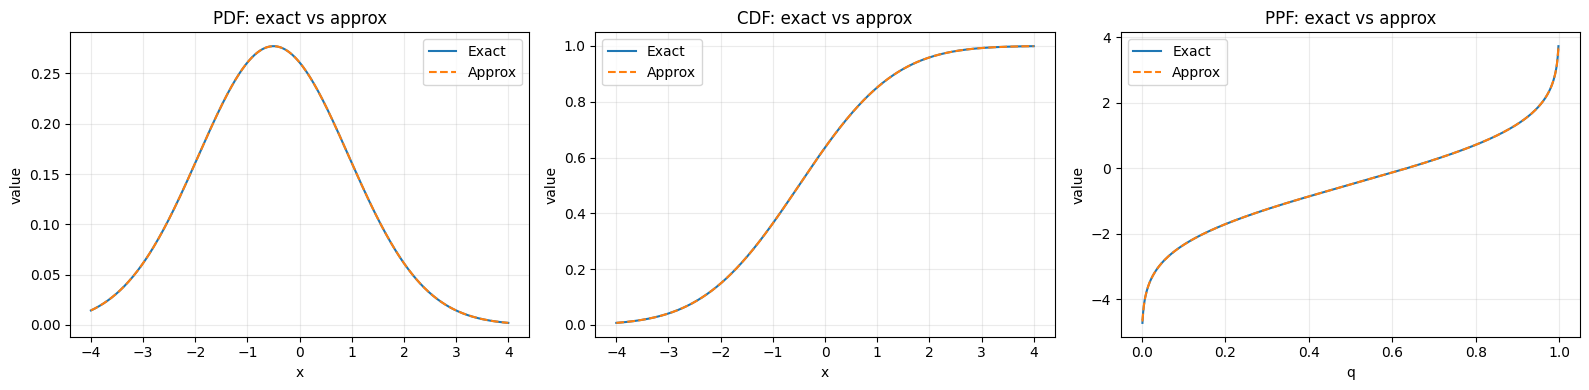

In [11]:
x_cmp = np.linspace(-4.0, 4.0, 600)
q_cmp = np.linspace(0.0, 1.0, 600)

exact_pdf = _method_values(affine_pos, CharacteristicName.PDF, x_cmp)
approx_pdf = _method_values(approximated_affine, CharacteristicName.PDF, x_cmp)
exact_cdf = _method_values(affine_pos, CharacteristicName.CDF, x_cmp)
approx_cdf = _method_values(approximated_affine, CharacteristicName.CDF, x_cmp)
exact_ppf = _method_values(affine_pos, CharacteristicName.PPF, q_cmp)
approx_ppf = _method_values(approximated_affine, CharacteristicName.PPF, q_cmp)

print("Max |PDF error|:", float(np.max(np.abs(exact_pdf - approx_pdf))))
print("Max |CDF error|:", float(np.max(np.abs(exact_cdf - approx_cdf))))
print("Max |PPF error|:", float(np.max(np.abs(exact_ppf - approx_ppf))))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
plot_curve(axes[0], x_cmp, exact_pdf, label="Exact", title="PDF: exact vs approx")
axes[0].plot(x_cmp, approx_pdf, linestyle="--", label="Approx")
axes[0].legend()

plot_curve(axes[1], x_cmp, exact_cdf, label="Exact", title="CDF: exact vs approx")
axes[1].plot(x_cmp, approx_cdf, linestyle="--", label="Approx")
axes[1].legend()

plot_curve(axes[2], q_cmp, exact_ppf, label="Exact", title="PPF: exact vs approx", xlabel="q")
axes[2].plot(q_cmp, approx_ppf, linestyle="--", label="Approx")
axes[2].legend()

plt.tight_layout()
plt.show()

## 5) Quick Summary

- `affine`, `binary`, and `finite_mixture` create `DerivedDistribution` objects.
- Operator overloads route to the same transformation primitives.
- Sampling is available through `distribution.sample(...)` for transformed objects.
- Approximation utilities can materialize selected characteristics while preserving a consistent interface.